## Normal SVD Image Compression
Download packages if running for the very 1st time

should only take 5min tops

In [1]:
using Pkg
Pkg.add("Images")
Pkg.add("FileIO")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [2]:
using Images, FileIO, LinearAlgebra, Statistics

Load your image (change the name duh).

In [4]:
img1 = load("imgs/sivka.jpg")
typeof(img1), size(img1)

(Matrix{RGB{N0f8}}, (2000, 1006))

Convert to grayscale and SVD the image matrix (its simpler with grayscale).

In [5]:
grayscale = Float64.(Gray.(img1)) #svd() dela sm na floatih
U, S, V = svd(grayscale)

SVD{Float64, Float64, Matrix{Float64}, Vector{Float64}}
U factor:
2000×1006 Matrix{Float64}:
 -0.0153215  0.000867846  0.00867285  …   0.0165926   -0.00251105
 -0.015334   0.0008646    0.00877483      0.0345979   -0.0129481
 -0.0152675  0.000690743  0.00871732     -0.0180106   -0.0124743
 -0.0152489  0.000698801  0.00887231     -0.0134119    0.000990488
 -0.0152418  0.000701469  0.00890604     -0.0442628    0.0140683
 -0.0152064  0.000605794  0.00879339  …   0.0504145   -0.0146199
 -0.0152393  0.000759598  0.0086375       0.00891051  -0.0157386
 -0.0152766  0.000909617  0.00823164      0.00616866  -0.00617106
 -0.0152781  0.000862096  0.00786995      0.00493535  -0.00725131
 -0.0153624  0.000898006  0.0073441      -0.0563397    0.0352214
  ⋮                                   ⋱                ⋮
 -0.0255166  0.00970547   0.00334004     -0.0394737   -0.0122206
 -0.0254392  0.00986872   0.00324935     -0.0165189    0.0106968
 -0.0254763  0.00983403   0.00325005      0.0345996   -0.0224586


Choose r-number of singular values and construct their SVD image.

In [6]:
images = []
err = []

for r in 1:5:50
    Ur = U[:, 1:r]
    Sr = Diagonal(S[1:r])
    Vr = V[:, 1:r]
    recon = Ur * Sr * transpose(Vr)
    recon =Gray.(recon)
    push!(images,recon)
    # mean absolute error over all pixels
    e = mean(abs.(grayscale .- recon))
    push!(err,round(Float64(e),digits=5))
end
print("Error percentage for each image:\n")
err


Error percentage for each image:


10-element Vector{Any}:
 0.15509
 0.06629
 0.04931
 0.03909
 0.03271
 0.02942
 0.02691
 0.0248
 0.02297
 0.02137

Look at the cool images :D 

(`rows x cols` must equal the number of images efcourse)

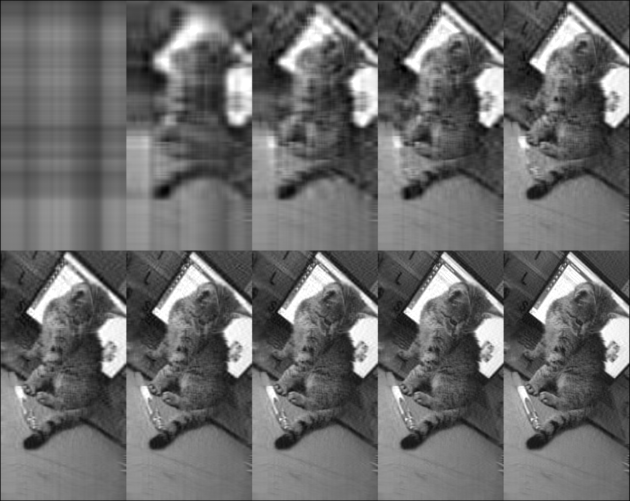

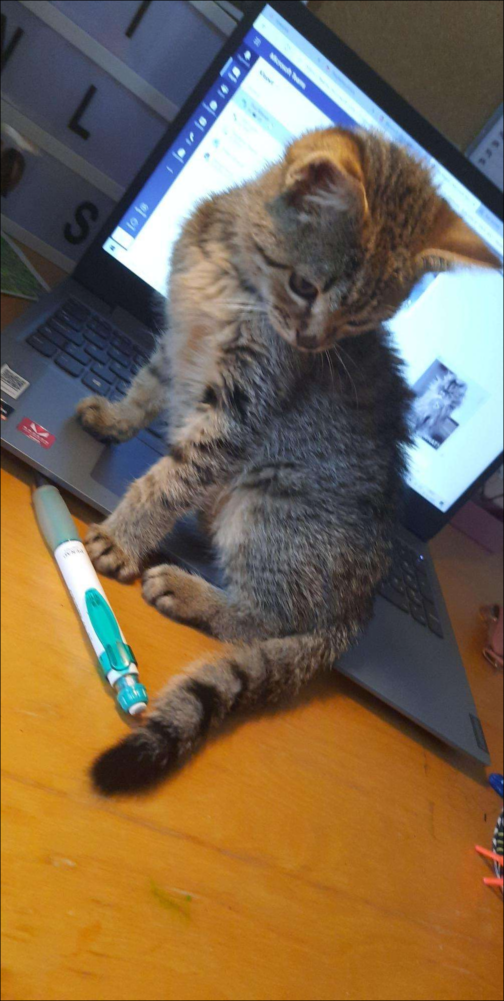

In [9]:
# rows*cols == size(images) !!!!!
rows = 2
cols = 5
row_images = [hcat(images[(r-1)*cols + 1 : r*cols]...) for r in 1:rows]
display(vcat(row_images...))
display(img1) # original img